<a href="https://colab.research.google.com/github/Quantum00000/Kaggle_Compititions/blob/main/Titanic_Machine_Learning_from_Disaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("train (1).csv")

In [ ]:
test_df=pd.read_csv("test (1).csv")


In [ ]:
x_train=df.drop('Survived',axis=1)
x_train=x_train.drop('Name',axis=1)
x_train=x_train.drop(['Ticket','PassengerId'],axis=1)
x_test=test_df.drop(['Ticket','PassengerId','Name'],axis=1)

In [ ]:
x_train.Cabin.fillna(0,inplace=True)
x_train['Cabin']=(x_train['Cabin']!=0).astype(int)
x_train['Sex']=(x_train['Sex']=='female').astype(int)
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
encoder.fit(x_train[['Embarked']])
x_train['Embarked']=encoder.transform(x_train[['Embarked']])

/tmp/ipykernel_5405/4058120945.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train.Cabin.fillna(0,inplace=True)


In [ ]:
x_test.Cabin.fillna(0,inplace=True)
x_test['Cabin']=(x_test['Cabin']!=0).astype(int)
x_test['Sex']=(x_test['Sex']=='female').astype(int)
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
encoder.fit(x_test[['Embarked']])
x_test['Embarked']=encoder.transform(x_test[['Embarked']])

/tmp/ipykernel_5405/2859130282.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_test.Cabin.fillna(0,inplace=True)


In [ ]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='mean')
imputer.fit(x_train[['Age']])
x_train[['Age']]=imputer.transform(x_train[['Age']])
imputer2=SimpleImputer(strategy='most_frequent')
imputer2.fit(x_train[['Embarked']])
x_train[['Embarked']]=imputer2.transform(x_train[['Embarked']])

In [ ]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='mean')
imputer.fit(x_test[['Age']])
x_test[['Age']]=imputer.transform(x_test[['Age']])
imputer2=SimpleImputer(strategy='most_frequent')
imputer2.fit(x_test[['Embarked']])
x_test[['Embarked']]=imputer2.transform(x_test[['Embarked']])
x_test['Fare']=x_test['Fare'].fillna(x_test['Fare'].mean())

In [ ]:
x_train.isnull().sum(),x_test.isnull().sum()


(Pclass      0
 Sex         0
 Age         0
 SibSp       0
 Parch       0
 Fare        0
 Cabin       0
 Embarked    0
 dtype: int64,
 Pclass      0
 Sex         0
 Age         0
 SibSp       0
 Parch       0
 Fare        0
 Cabin       0
 Embarked    0
 dtype: int64)

In [ ]:
y_train=df['Survived']

In [ ]:
y_train

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [ ]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,0,22.000000,1,0,7.2500,0,0.0
1,1,1,38.000000,1,0,71.2833,1,1.0
2,3,1,26.000000,0,0,7.9250,0,0.0
3,1,1,35.000000,1,0,53.1000,1,0.0
4,3,0,35.000000,0,0,8.0500,0,0.0
...,...,...,...,...,...,...,...,...
886,2,0,27.000000,0,0,13.0000,0,0.0
887,1,1,19.000000,0,0,30.0000,1,0.0
888,3,1,29.699118,1,2,23.4500,0,0.0
889,1,0,26.000000,0,0,30.0000,1,1.0


In [ ]:
cor_all_column=x_train.corrwith(y_train)

In [ ]:
cor_all_column

,0
Pclass,-0.338481
Sex,0.543351
Age,-0.069809
SibSp,-0.035322
Parch,0.081629
Fare,0.257307
Cabin,0.316912
Embarked,0.168240


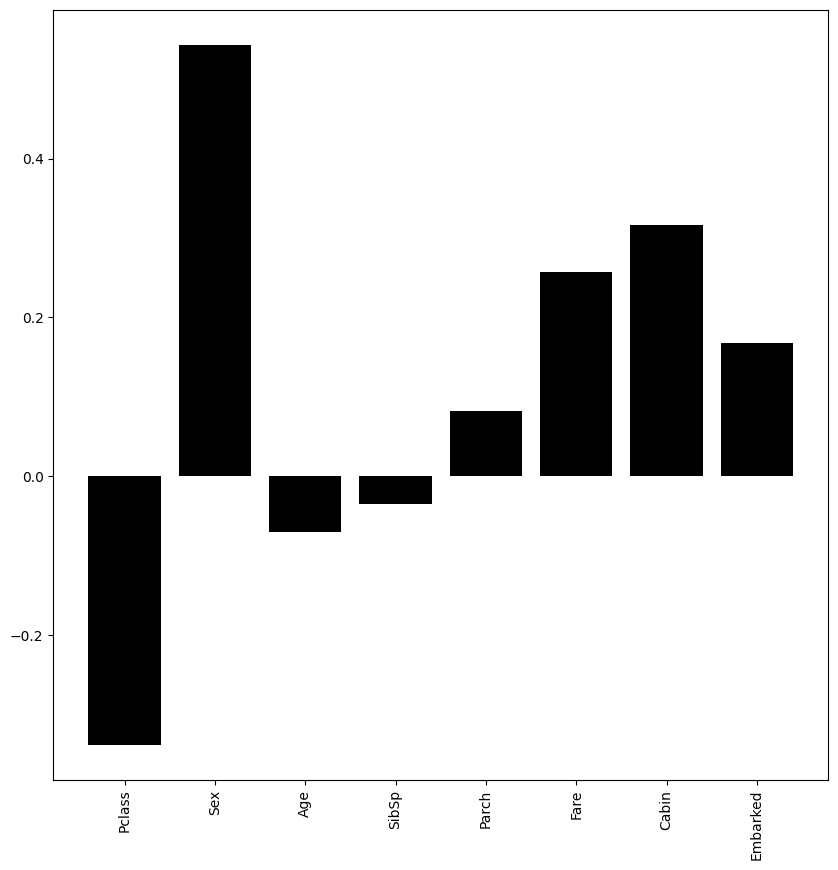

In [ ]:
plt.figure(figsize=(10,10))
plt.bar(cor_all_column.index,cor_all_column,color='black')
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
x_train=torch.tensor(x_train.values,dtype=torch.float32)
y_train=torch.tensor(y_train.values,dtype=torch.float32)
x_test=torch.tensor(x_test.values,dtype=torch.float32)

In [ ]:
from torch import nn
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
class Model01(nn.Module):
  def __init__(self):
    super().__init__()
    self.innerlayer1=nn.Linear(in_features=8,out_features=10)
    self.innerlayer2=nn.Linear(in_features=10,out_features=10)
    self.innerlayer2=nn.Linear(in_features=10,out_features=10)
    self.outerlayer=nn.Linear(in_features=10,out_features=1)
  def forward(self,x):
    return self.outerlayer(self.innerlayer2(self.innerlayer1(x)))

In [ ]:
model=Model01().to(device)

In [ ]:
model

Model01(
  (innerlayer1): Linear(in_features=8, out_features=10, bias=True)
  (innerlayer2): Linear(in_features=10, out_features=10, bias=True)
  (outerlayer): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.001)
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc

In [ ]:
torch.manual_seed(42)
epoches=1000
x_train=x_train.to(device)
y_train=y_train.to(device)
x_test=x_test.to(device)
for epoch in range (epoches):
  model.train()
  logits=model(x_train).squeeze()
  y_pred=torch.round(torch.sigmoid(logits))

  loss=loss_fn(logits,y_train)
  accuracy=accuracy_fn(y_train,y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model.eval()
  with torch.inference_mode():
    test_logits=model(x_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))
  if (epoch % 100==0 ):
    print(f"epoch:{epoch},loss:{loss},accuracy:{accuracy}")


epoch:0,loss:0.4500061571598053,accuracy:80.13468013468014
epoch:100,loss:0.44957417249679565,accuracy:80.13468013468014
epoch:200,loss:0.44916051626205444,accuracy:80.13468013468014
epoch:300,loss:0.4487643837928772,accuracy:80.02244668911335
epoch:400,loss:0.4483851194381714,accuracy:80.02244668911335
epoch:500,loss:0.44802194833755493,accuracy:80.02244668911335
epoch:600,loss:0.44767406582832336,accuracy:80.13468013468014
epoch:700,loss:0.4473409056663513,accuracy:80.13468013468014
epoch:800,loss:0.4470217227935791,accuracy:80.13468013468014
epoch:900,loss:0.4467160403728485,accuracy:80.13468013468014


In [ ]:
test_pred.size()

torch.Size([418])

In [ ]:
submit=pd.DataFrame({
    'PassengerId':test_df['PassengerId'],
    'Survived':test_pred.to(device).numpy().astype(int)
})
submit.to_csv('titanic_submission.csv',index=False)

In [ ]:
submit

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
